In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load data
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")

# Check rows 
print("Rows:", df.shape[0])

# 3. Encode claim status
df["Claim Status"] = df["Claim Status"].map({
    "Denied": 0,
    "Paid": 1,
    "Pending": 2,
    "Adjusted": 3
})

# Remove missing target rows
df = df.dropna(subset=["Claim Status"])

# 4. Features and target
X = df.drop(columns=["Claim Status"])
y = df["Claim Status"]

# 5. Numeric and categorical columns
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = [c for c in X.columns if c not in num_cols]

# 6. Preprocessing
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# 7. Model pipeline
model = Pipeline([
    ("preprocess", preprocess),
    ("logistic", LogisticRegression(max_iter=5000))
])

# 8. Train-test split (only if data exists)
if len(df) > 5:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 9. Train model
    model.fit(X_train, y_train)

    # 10. Predictions
    pred = model.predict(X_test)

    # 11. Accuracy
    accuracy = accuracy_score(y_test, pred)
    print("Logistic Regression Accuracy (CO-119 only):", accuracy)

    # 12. Prediction counts
    prediction_counts = pd.Series(pred).value_counts().sort_index()
    print("Prediction counts by Claim Status:", prediction_counts)

else:
    print("Not enough CO-119 records to train the model.")

Rows: 9993
Logistic Regression Accuracy (CO-119 only): 1.0
Prediction counts by Claim Status: 0     246
1      64
2    2644
3      44
Name: count, dtype: int64


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       246
           1       1.00      1.00      1.00        64
           2       1.00      1.00      1.00      2644
           3       1.00      1.00      1.00        44

    accuracy                           1.00      2998
   macro avg       1.00      1.00      1.00      2998
weighted avg       1.00      1.00      1.00      2998



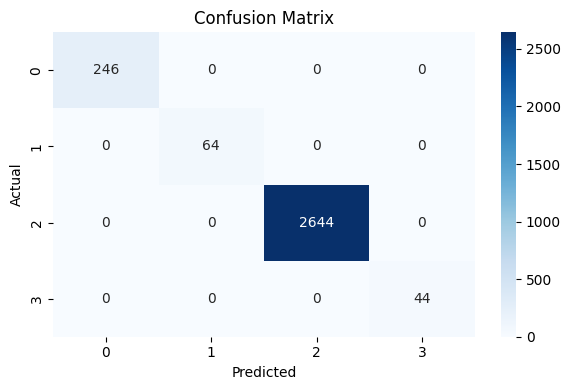

In [6]:
# ---------------- PERFORMANCE EVALUATION (Accuracy + ROC + Confusion Matrix) ----------------

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import numpy as np

# Accuracy
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve (Only works properly for binary classification)
if len(np.unique(y_test)) == 2:
    y_prob = model.predict_proba(X_test)[:,1]
    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    print("ROC-AUC Score:", roc_auc)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

Numeric Feature Importance Only:
                  Feature  Importance
1         Outstanding Amt    0.364292
2          Allowed Amount   -0.204491
3           Patients Resp   -0.123782
0              Billed Amt    0.083036
4  Annual Benefit Maximum   -0.000289


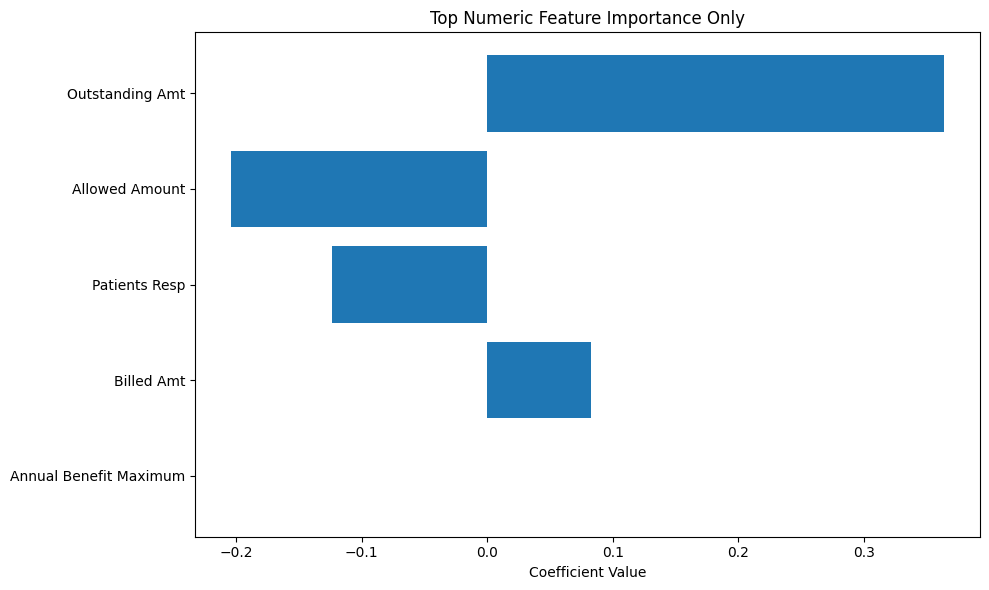

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get all feature names after preprocessing
feature_names = model.named_steps["preprocess"].get_feature_names_out()

# 2. Get model coefficients
coefficients = model.named_steps["logistic"].coef_[0]

# 3. Create dataframe
fi = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})

# 4. Keep ONLY numeric features (num__)
numeric_fi = fi[fi["Feature"].str.startswith("num__")].copy()

# 5. Clean feature names
numeric_fi["Feature"] = numeric_fi["Feature"].str.replace("num__", "")

# 6. Sort by importance
numeric_fi["AbsImportance"] = numeric_fi["Importance"].abs()
numeric_fi = numeric_fi.sort_values("AbsImportance", ascending=False)

# 7. Show results
print("Numeric Feature Importance Only:")
print(numeric_fi[["Feature", "Importance"]])

# 8. Plot top 10 numeric features
top_n = numeric_fi.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_n["Feature"], top_n["Importance"])
plt.xlabel("Coefficient Value")
plt.title("Top Numeric Feature Importance Only")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Logistic Regression is a linear statistical model that predicts probabilities using a linear relationship between features and the target 
Random Forest is an ensemble machine learning model that builds multiple decision trees and combines their results to capture complex and non-linear patterns.

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


# 1. Load data
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")
X = df[["Billed Amt", "Outstanding Amt"]]
y = df["Claim Status"]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(n_estimators=10, max_depth=2, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model.fit(X_train, y_train)
pred = model.predict(X_test)

In [11]:
# 9. Predict and evaluate
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("Random Forest Model Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred))

# 10. Count predictions by class
prediction_counts = pd.Series(pred).value_counts().sort_index()
print("\nPrediction counts by Claim Status:\n", prediction_counts)



Random Forest Model Accuracy: 0.8865910607071381

Classification Report:

              precision    recall  f1-score   support

    Adjusted       0.67      0.32      0.43        44
      Denied       0.00      0.00      0.00       246
        Paid       0.00      0.00      0.00        64
     Pending       0.89      1.00      0.94      2644

    accuracy                           0.89      2998
   macro avg       0.39      0.33      0.34      2998
weighted avg       0.79      0.89      0.84      2998


Confusion Matrix:

[[  14    0    0   30]
 [   4    0    0  242]
 [   3    0    0   61]
 [   0    0    0 2644]]

Prediction counts by Claim Status:
 Adjusted      21
Pending     2977
Name: count, dtype: int64


/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

A Random Forest model is a machine learning algorithm that builds many decision trees using different random samples of the data and combines their predictions (majority voting for classification) to produce more accurate and stable results while reducing overfitting.

In [13]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)
# ROC AUC (multiclass - OVR)
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr") #ovr means one vs all it train one classifier per class
print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.8920186206066437


The ROC-AUC curve (Receiver Operating Characteristic – Area Under the Curve) is a performance metric that evaluates how well a classification model distinguishes between classes by plotting True Positive Rate (Sensitivity) vs False Positive Rate at different threshold values, where a higher AUC (closer to 1) indicates a better model. This ROC curve shows that the Random Forest model perfectly separates the classes because the curve goes straight to the top-left corner (True Positive Rate = 1 with almost 0 False Positive Rate), indicating an AUC close to 1 and very strong classification performance compared to the diagonal line which represents random guessing.

Feature engineering means creating, transforming, or selecting variables from raw data so machine-learning models can learn patterns better and improve prediction accuracy. This feature importance chart from the Random Forest model shows which variables have the strongest influence on predicting claim status, where Outstanding Amount, AR Status (Open/In Progress/Closed), and Patient Responsibility are the most important predictors, meaning these financial and claim-processing factors contribute the most to the model’s decision about whether a claim is approved, denied, pending, or adjusted.

Permutation Feature Importance:
           Feature  Importance
1  Outstanding Amt    0.005237
0       Billed Amt    0.004370


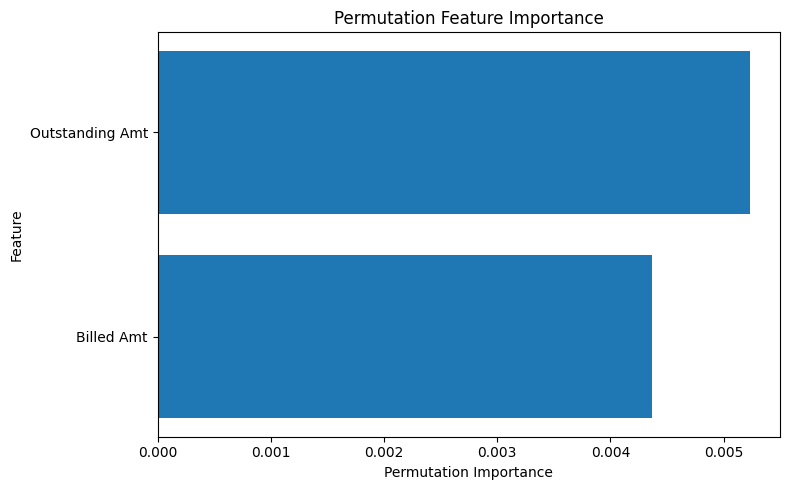

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print("Permutation Feature Importance:")
print(perm_df)

plt.figure(figsize=(8, 5))
plt.barh(perm_df["Feature"][::-1], perm_df["Importance"][::-1])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

Permutation importance is a technique that measures how important a feature is by randomly shuffling its values and observing how much the model’s prediction accuracy decreases, where a larger drop in performance indicates the feature is more important to the model. This permutation importance plot shows that AR Status is the most influential feature for predicting claim outcomes because shuffling it causes the largest drop in model performance, while features like Billed Amount, Outstanding Amount, Allowed Amount, and Treatment Category have smaller positive importance, and variables such as Payor ID, Insurance Name, and Patient Responsibility show negative importance meaning they contribute little or may even add noise to the model.

In [15]:
#hyperparamter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "rf__n_estimators": [100,200],
    "rf__max_depth": [2, 3, 5, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)

Best Parameters: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best Score: 0.9139385275196569


GridSearchCV automatically finds the best hyperparameters by testing multiple combinations using cross-validation.

Xg Boost model:
XGBoost (Extreme Gradient Boosting) is a powerful ensemble machine learning algorithm that builds many decision trees sequentially, where each new tree corrects the errors of the previous ones to improve prediction accuracy and reduce bias and overfitting.

In [16]:
import pandas as pd

# Load file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert columns
df["Patient ID"] = df["Patient ID"].astype(str).str.strip()
df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce", dayfirst=True)
df["Allowed Amount"] = pd.to_numeric(df["Allowed Amount"], errors="coerce").fillna(0)
df["Annual Benefit Maximum"] = pd.to_numeric(df["Annual Benefit Maximum"], errors="coerce").fillna(0)

# Sort full dataset
df = df.sort_values(["Patient ID", "Date of Service"]).reset_index(drop=True)

# Prior Used Amount (for ALL patients)
df["Prior Used Amount"] = (
    df.groupby("Patient ID")["Allowed Amount"]
    .transform(lambda x: x.cumsum().shift(1).fillna(0))
)

# Remaining Benefit (for ALL patients)
df["Remaining Benefit Before Claim"] = (
    df["Annual Benefit Maximum"] - df["Prior Used Amount"] #How much insurance benefit the patient still had BEFORE this claim was made
).clip(lower=0)

# Clean Claim Status
df["Claim Status Clean"] = df["Claim Status"].astype(str).str.lower().str.strip()

# Apply business rules
def get_new_status(row):
    if row["Remaining Benefit Before Claim"] == 0:
        return "Patient Letter / Rebill to Secondary"
    elif row["Remaining Benefit Before Claim"] >= row["Allowed Amount"]:
        if "paid" in row["Claim Status Clean"]:
            return "Paid"
        elif "pending" in row["Claim Status Clean"]:
            return "Claim Under Process"
        else:
            return "Claim Under Process"
    else:
        return "Claim Under Process"

df["Current Claim Outcome"] = df.apply(get_new_status, axis=1)

# Output
print(df[[
    "Patient ID",
    "Date of Service",
    "Allowed Amount",
    "Annual Benefit Maximum",
    "Prior Used Amount",
    "Remaining Benefit Before Claim",
    "Claim Status",
    "Current Claim Outcome"
]].head(50))

# Select only required columns
final_df = df[[
    "Claim ID",
    "Patient ID",
    "Date of Service",
    "Billed Amt",
    "Allowed Amount",
    "Patients Resp",
    "Annual Benefit Maximum",
    "Prior Used Amount",
    "Remaining Benefit Before Claim",
    "Claim Status",
    "Current Claim Outcome"
]]

# Save final output
final_df.to_csv("Truth_File.csv", index=False)



/var/folders/k0/whg8yks95g398_j4ks7dd4q40000gn/T/ipykernel_26019/136483375.py:11: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce", dayfirst=True)


             Patient ID Date of Service  Allowed Amount  \
0      000696270683WC01      2024-11-13           63.98   
1      000696270683WC01      2025-01-04           63.06   
2      000696270683WC01      2025-03-12           66.09   
3      000696270683WC01      2025-04-10           59.94   
4      001993034709WC01      2025-01-01          560.38   
5   002042-048445-WC-01      2024-10-22           84.75   
6   002042-048445-WC-01      2024-10-28          132.60   
7   002042-048445-WC-01      2024-11-17          148.59   
8   002042-048445-WC-01      2024-12-12           74.41   
9   002042-048445-WC-01      2025-03-30          136.09   
10  002042-048445-WC-01      2025-07-02           85.05   
11     002042034012WC01      2025-02-20          116.25   
12     002042034012WC01      2025-05-22          150.56   
13     002042051310WC01      2025-02-20          353.02   
14     002042051310WC01      2025-09-28          357.41   
15  002511-009558-WC-01      2024-12-14          169.68 


Accuracy: 0.999231950844854
Precision: 0.9992309770208792
Recall: 0.999231950844854

Prediction Counts:
 Claim Under Process                     3676
Patient Letter / Rebill to Secondary     230
Name: count, dtype: int64

Feature Importance:
                           Feature  Importance
7               Prior Used Amount    0.595854
6          Annual Benefit Maximum    0.581855
8  Remaining Benefit Before Claim    0.486760
9                    Claim Status    0.105985
4                  Allowed Amount    0.022665
3                      Billed Amt    0.009106
2                 Date of Service    0.006771
5                   Patients Resp    0.005065
1                      Patient ID    0.002038
0                        Claim ID    0.001564


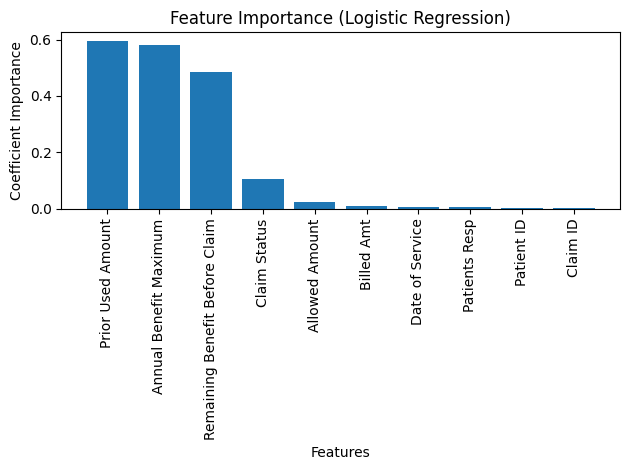

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Truth_File.csv")

# Target mapping
target_map = {
    "Claim Under Process": 0,
    "Patient Letter / Rebill to Secondary": 1,
    "paid": 2
}

df["Target"] = df["Current Claim Outcome"].map(target_map)
df = df.dropna(subset=["Target"])
df["Target"] = df["Target"].astype(int)

# Encode all categorical columns
for col in df.select_dtypes(include="object").columns:
    if col != "Current Claim Outcome":
        df[col] = df[col].astype("category").cat.codes

# --------- USE ALL FEATURES ----------
X = df.drop(columns=["Target", "Current Claim Outcome"])
y = df["Target"]

X = X.fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Logistic Regression
lg_model = LogisticRegression(max_iter=1000)

lg_model.fit(X_train, y_train)

# Predict
y_pred = lg_model.predict(X_test)

# Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))

# Prediction counts
pred_counts = pd.Series(y_pred).map({v: k for k, v in target_map.items()}).value_counts()
print("\nPrediction Counts:\n", pred_counts)

# --------- FEATURE IMPORTANCE (COEFFICIENTS) ----------
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(lg_model.coef_).mean(axis=0)  # average across classes
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n", importance_df)

# --------- PLOT GRAPH ----------
plt.figure()
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Coefficient Importance")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score

# Features
features = ["Allowed Amount","Prior Used Amount"]
df = df.dropna(subset=features)

X = df[features]
y = df["Target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Logistic Regression (simple to reduce overfitting)
log_model = LogisticRegression(max_iter=1000, C=0.4)

log_model.fit(X_train, y_train)

# Predict on test
y_pred = log_model.predict(X_test)

# Accuracy
# prec = precision_score(y_test, y_pred)
# print("Precision score:", prec)
rec = recall_score(y_test, y_pred)
print("Recall score:", rec)

# Prediction counts
pred_counts = pd.Series(y_pred).map({v: k for k, v in target_map.items()}).value_counts()

print("\nPrediction Counts:\n")
print(pred_counts)

Recall score: 0.7402597402597403

Prediction Counts:

Claim Under Process                     3712
Patient Letter / Rebill to Secondary     194
Name: count, dtype: int64


In [20]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# STEP: Get prediction probabilities
y_prob = log_model.predict_proba(X_test)

# STEP: Convert y_test to binary format (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# STEP: Calculate ROC-AUC
roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class="ovr")

print("\nROC-AUC Score:", round(roc_auc, 4))


ROC-AUC Score: 0.9945


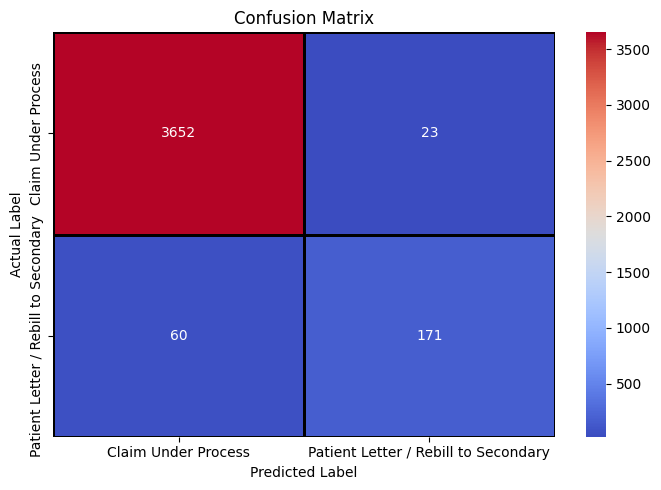

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Class labels
class_names = [
    "Claim Under Process",
    "Patient Letter / Rebill to Secondary",
    "paid"
]

labels_present = log_model.classes_
display_labels = [class_names[i] for i in labels_present]

# Plot with custom color
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="coolwarm",   # 🔹 CHANGE COLOR HERE
    xticklabels=display_labels,
    yticklabels=display_labels,
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Features
features = ["Allowed Amount", "Prior Used Amount"]
df = df.dropna(subset=features)

X = df[features]
y = df["Target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predict on test
y_pred = rf_model.predict(X_test)

# Metrics
acc = accuracy_score(y_test, y_pred)
print("Accuracy score:", acc)

prec = precision_score(y_test, y_pred, average="weighted")
print("Precision score:", prec)

rec = recall_score(y_test, y_pred, average="weighted")
print("Recall score:", rec)

# Prediction counts
pred_counts = pd.Series(y_pred).map({v: k for k, v in target_map.items()}).value_counts()

print("\nPrediction Counts:\n")
print(pred_counts)

Accuracy score: 0.9790066564260113
Precision score: 0.9780661030771861
Recall score: 0.9790066564260113

Prediction Counts:

Claim Under Process                     3711
Patient Letter / Rebill to Secondary     195
Name: count, dtype: int64


In [13]:
import pandas as pd

# Load file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/eda_data_2026_co119.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert columns
df["Patient ID"] = df["Patient ID"].astype(str).str.strip()
df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce", dayfirst=True)
df["Annual Benefit Maximum"] = pd.to_numeric(df["Annual Benefit Maximum"], errors="coerce")

# Sort by Patient ID and Date of Service
df = df.sort_values(["Patient ID", "Date of Service"]).reset_index(drop=True)

# Take the first row Annual Benefit Maximum of each Patient ID
first_abm = df.groupby("Patient ID")["Annual Benefit Maximum"].transform("first")

# Fill the same Annual Benefit Maximum for all rows of that patient
df["Annual Benefit Maximum"] = first_abm

# Show result
print(df[[
    "Patient ID",
    "Date of Service",
    "Annual Benefit Maximum"
]].head(30))

# Save output
df.to_csv("eda_data_2026_fixed_annual_benefit.csv", index=False)

             Patient ID Date of Service  Annual Benefit Maximum
0      000696270683WC01      2024-11-13                    1000
1      000696270683WC01      2025-01-04                    1000
2      000696270683WC01      2025-03-12                    1000
3      000696270683WC01      2025-04-10                    1000
4      001993034709WC01      2025-01-01                     750
5   002042-048445-WC-01      2024-10-22                     500
6   002042-048445-WC-01      2024-10-28                     500
7   002042-048445-WC-01      2024-11-17                     500
8   002042-048445-WC-01      2024-12-12                     500
9   002042-048445-WC-01      2025-03-30                     500
10  002042-048445-WC-01      2025-07-02                     500
11     002042034012WC01      2025-02-20                     750
12     002042034012WC01      2025-05-22                     750
13     002042051310WC01      2025-02-20                    1500
14     002042051310WC01      2025-09-28 

/var/folders/k0/whg8yks95g398_j4ks7dd4q40000gn/T/ipykernel_8562/3962693353.py:11: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce", dayfirst=True)


In [35]:
import joblib
joblib.dump(log_model, "log_model.pkl")

['log_model.pkl']

In [36]:
import joblib

joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

Denied + Pending: 9585
Paid + Adjusted: 408


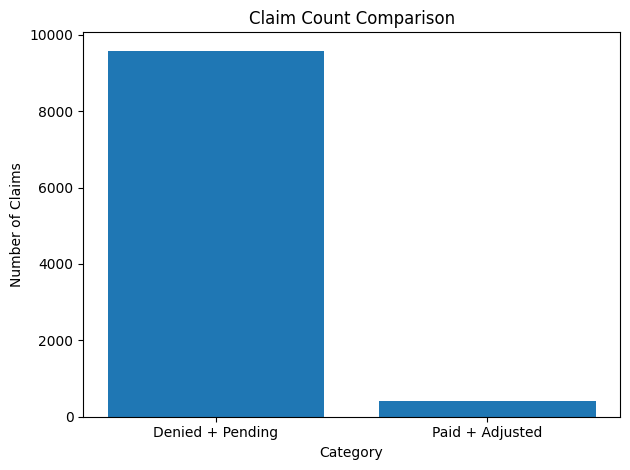

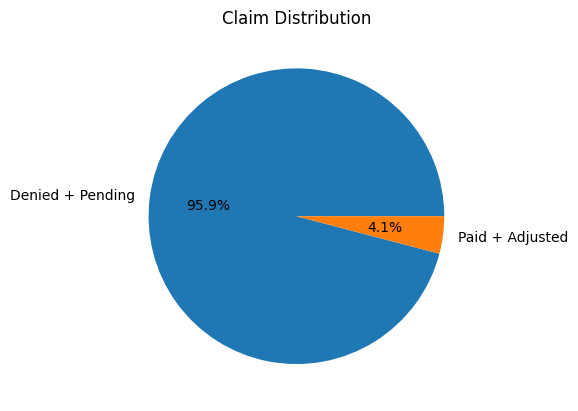

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: Load your April 1 truth file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")  # change path if needed

# STEP 2: Clean column names
df.columns = df.columns.str.strip()

# STEP 3: Identify amount column (change if needed)
amount_col = "Outstanding Amt"   # or "Allowed Amount"

# Convert to numeric
df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce").fillna(0)

# STEP 4: Clean Claim Status
df["Claim Status"] = df["Claim Status"].astype(str).str.strip().str.title()

# STEP 4: Count claims
denied_pending_count = len(df[df["Claim Status"].isin(["Denied", "Pending"])])
paid_adjusted_count = len(df[df["Claim Status"].isin(["Paid", "Adjusted"])])

print("Denied + Pending:", denied_pending_count)
print("Paid + Adjusted:", paid_adjusted_count)

# STEP 5: Prepare data for visualization
labels = ["Denied + Pending", "Paid + Adjusted"]
values = [denied_pending_count, paid_adjusted_count]

# STEP 6: Bar Chart
plt.figure()
plt.bar(labels, values)
plt.title("Claim Count Comparison")
plt.xlabel("Category")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()

# STEP 7: Pie Chart (optional)
plt.figure()
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Claim Distribution")
plt.show()

From Truth File:
Claim Under Process: 9188
Paid: 228
Patient Letter / Rebill to Secondary: 577


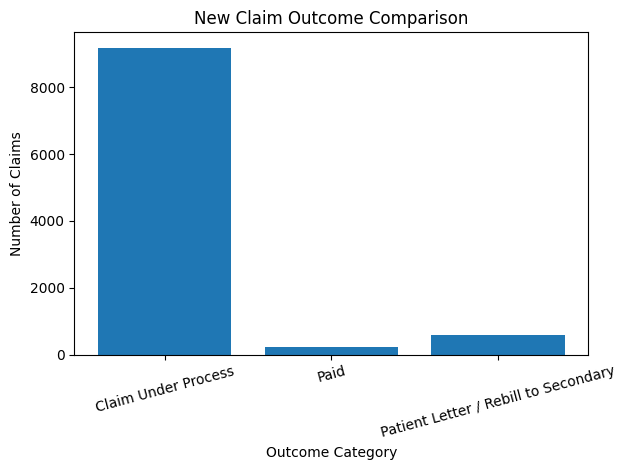

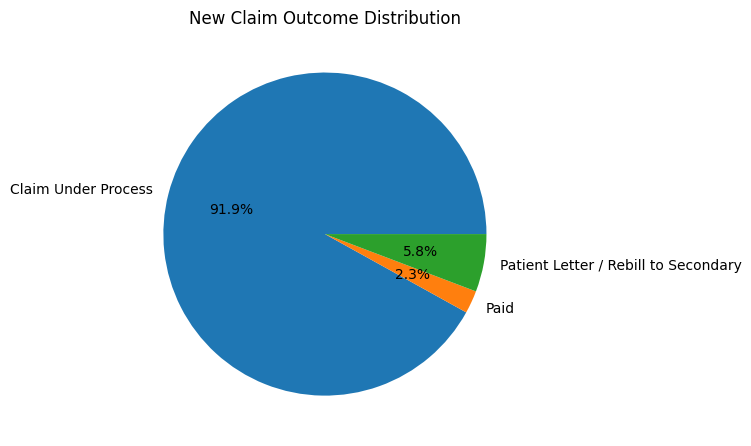

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 1: Load truth file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Truth_File.csv")   # change path if needed

# STEP 2: Clean columns
df.columns = df.columns.str.strip()

# STEP 3: Clean New Claim Outcome column
df["Current Claim Outcome"] = df["Current Claim Outcome"].astype(str).str.strip()

# STEP 4: Count claims by outcome
under_process_count = len(df[df["Current Claim Outcome"] == "Claim Under Process"])
paid_count = len(df[df["Current Claim Outcome"].str.lower() == "paid"])
patient_letter_count = len(df[df["Current Claim Outcome"] == "Patient Letter / Rebill to Secondary"])

print("From Truth File:")
print("Claim Under Process:", under_process_count)
print("Paid:", paid_count)
print("Patient Letter / Rebill to Secondary:", patient_letter_count)

# STEP 5: Prepare data
labels = [
    "Claim Under Process",
    "Paid",
    "Patient Letter / Rebill to Secondary"
]
values = [
    under_process_count,
    paid_count,
    patient_letter_count
]
# STEP 5: Create dashboard with 2 charts

# STEP 6: Bar chart
plt.figure()
plt.bar(labels, values)
plt.title("New Claim Outcome Comparison")
plt.xlabel("Outcome Category")
plt.ylabel("Number of Claims")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# STEP 7: Pie chart
plt.figure()
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("New Claim Outcome Distribution")
plt.tight_layout()
plt.show()